# Exploración: intención de compra en sesiones online

Objetivo: describir la calidad, el desbalance y los patrones de conversión que soportan la pregunta de negocio. Los duplicados exactos se reportan, pero no se eliminan: el dataset no contiene un identificador de sesión y dos usuarios pueden compartir el mismo vector.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

from online_shoppers.data import dataset_summary, load_dataset
from online_shoppers.reporting import build_eda_summary, write_json

ROOT = Path.cwd() if (Path.cwd() / 'pyproject.toml').exists() else Path.cwd().parent
DATA_PATH = ROOT / 'data/raw/online_shoppers_intention.csv'
REPORT_PATH = ROOT / 'reports/eda_summary.json'
FIGURES_PATH = ROOT / 'reports/figures'
FIGURES_PATH.mkdir(parents=True, exist_ok=True)
sessions = load_dataset(DATA_PATH)
dataset_summary(sessions)

{'rows': 12330,
 'columns': 18,
 'duplicate_rows': 125,
 'positive_count': 1908,
 'positive_rate': 0.15474452554744525}

In [2]:
summary = build_eda_summary(sessions)
write_json(REPORT_PATH, summary)
summary

{'rows': 12330,
 'columns': 18,
 'duplicate_rows': 125,
 'missing_values': {'Administrative': 0,
  'Administrative_Duration': 0,
  'Informational': 0,
  'Informational_Duration': 0,
  'ProductRelated': 0,
  'ProductRelated_Duration': 0,
  'BounceRates': 0,
  'ExitRates': 0,
  'PageValues': 0,
  'SpecialDay': 0,
  'Month': 0,
  'OperatingSystems': 0,
  'Browser': 0,
  'Region': 0,
  'TrafficType': 0,
  'VisitorType': 0,
  'Weekend': 0,
  'Revenue': 0},
 'dtypes': {'Administrative': 'int64',
  'Administrative_Duration': 'float64',
  'Informational': 'int64',
  'Informational_Duration': 'float64',
  'ProductRelated': 'int64',
  'ProductRelated_Duration': 'float64',
  'BounceRates': 'float64',
  'ExitRates': 'float64',
  'PageValues': 'float64',
  'SpecialDay': 'float64',
  'Month': 'object',
  'OperatingSystems': 'int64',
  'Browser': 'int64',
  'Region': 'int64',
  'TrafficType': 'int64',
  'VisitorType': 'object',
  'Weekend': 'bool',
  'Revenue': 'bool'},
 'positive_count': 1908,
 'pos

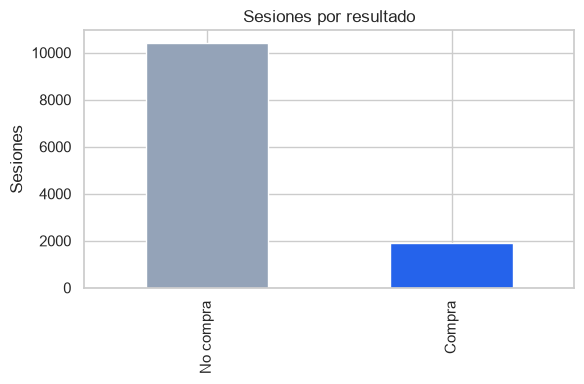

In [3]:
sns.set_theme(style='whitegrid')
fig, ax = plt.subplots(figsize=(6, 4))
sessions['Revenue'].value_counts().rename(index={False: 'No compra', True: 'Compra'}).plot.bar(ax=ax, color=['#94a3b8', '#2563eb'])
ax.set(title='Sesiones por resultado', xlabel='', ylabel='Sesiones')
fig.tight_layout()
fig.savefig(FIGURES_PATH / 'target_balance.png', dpi=150)
plt.show()

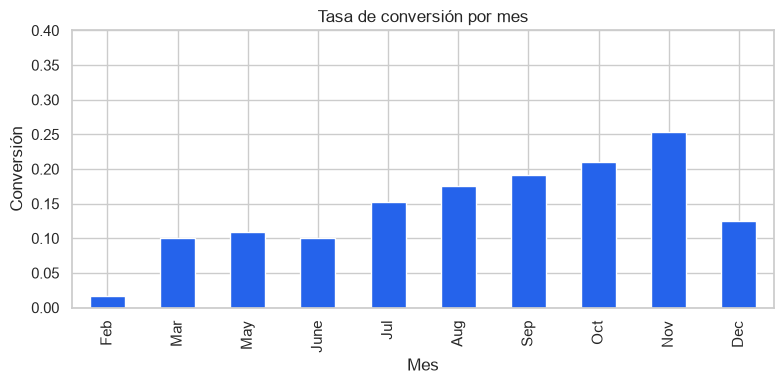

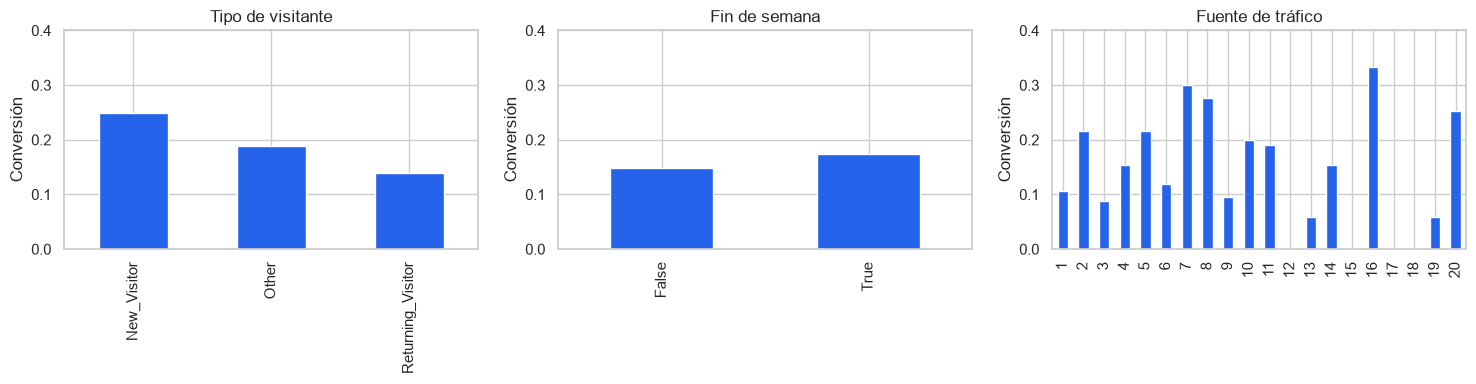

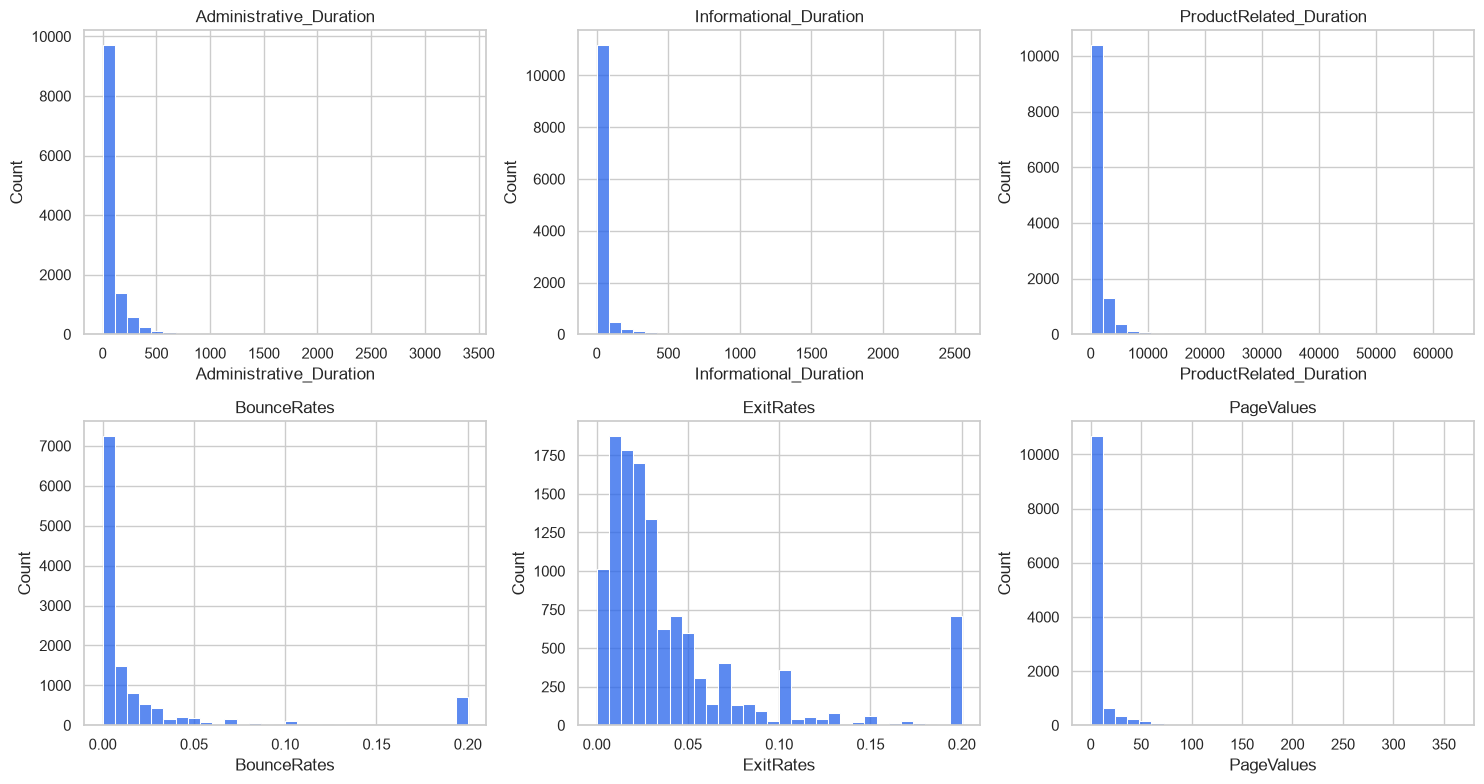

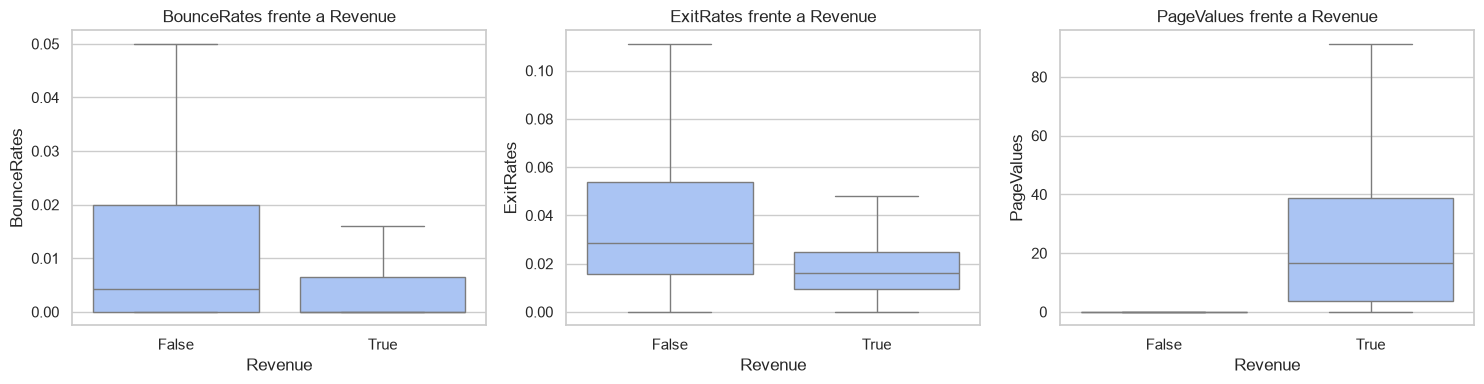

In [4]:
month_order = ['Feb', 'Mar', 'May', 'June', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
conversion = sessions.groupby('Month', observed=True)['Revenue'].mean().reindex(month_order)
fig, ax = plt.subplots(figsize=(8, 4))
conversion.plot.bar(ax=ax, color='#2563eb')
ax.set(title='Tasa de conversión por mes', xlabel='Mes', ylabel='Conversión', ylim=(0, max(0.4, conversion.max() * 1.1)))
fig.tight_layout()
fig.savefig(FIGURES_PATH / 'conversion_by_month.png', dpi=150)
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for axis, column, title in zip(
    axes,
    ['VisitorType', 'Weekend', 'TrafficType'],
    ['Tipo de visitante', 'Fin de semana', 'Fuente de tráfico'],
):
    sessions.groupby(column, observed=True)['Revenue'].mean().plot.bar(ax=axis, color='#2563eb')
    axis.set(title=title, xlabel='', ylabel='Conversión', ylim=(0, 0.4))
fig.tight_layout()
fig.savefig(FIGURES_PATH / 'conversion_by_context.png', dpi=150)
plt.show()

distribution_columns = [
    'Administrative_Duration', 'Informational_Duration',
    'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues',
]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for axis, column in zip(axes.flat, distribution_columns):
    sns.histplot(data=sessions, x=column, bins=30, ax=axis, color='#2563eb')
    axis.set_title(column)
fig.tight_layout()
fig.savefig(FIGURES_PATH / 'numeric_distributions.png', dpi=150)
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for axis, column in zip(axes, ['BounceRates', 'ExitRates', 'PageValues']):
    sns.boxplot(data=sessions, x='Revenue', y=column, ax=axis, color='#9ec1ff', showfliers=False)
    axis.set_title(f'{column} frente a Revenue')
fig.tight_layout()
fig.savefig(FIGURES_PATH / 'signals_by_revenue.png', dpi=150)
plt.show()

## Conclusiones

- La clase positiva es minoritaria, por lo que accuracy no será la métrica de selección.
- Mes, tipo de visitante y señales de navegación presentan tasas de conversión diferentes y aportan contexto descriptivo.
- PageValues debe tratarse con cautela porque su disponibilidad depende del momento de scoring; el entrenamiento compara variantes con y sin esa variable.
- El análisis es predictivo y no permite atribuir causalidad a una intervención comercial.